In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

In [2]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)

In [3]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:    (time: 564, nbnds: 2, lat: 73, lon: 144)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 9kB ...
    mslp       (time, lat, lon) float32 24MB ...
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [4]:
mn = ds.mean(dim = "time")

In [5]:
mn.mslp.lat

<xarray.DataArray 'lat' (lat: 73)> Size: 292B
array([ 90. ,  87.5,  85. ,  82.5,  80. ,  77.5,  75. ,  72.5,  70. ,  67.5,
        65. ,  62.5,  60. ,  57.5,  55. ,  52.5,  50. ,  47.5,  45. ,  42.5,
        40. ,  37.5,  35. ,  32.5,  30. ,  27.5,  25. ,  22.5,  20. ,  17.5,
        15. ,  12.5,  10. ,   7.5,   5. ,   2.5,   0. ,  -2.5,  -5. ,  -7.5,
       -10. , -12.5, -15. , -17.5, -20. , -22.5, -25. , -27.5, -30. , -32.5,
       -35. , -37.5, -40. , -42.5, -45. , -47.5, -50. , -52.5, -55. , -57.5,
       -60. , -62.5, -65. , -67.5, -70. , -72.5, -75. , -77.5, -80. , -82.5,
       -85. , -87.5, -90. ], dtype=float32)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
Attributes:
    units:               degrees_north
    actual_range:        [ 90. -90.]
    long_name:           Latitude
    standard_name:       latitude
    axis:                Y
    coordinate_defines:  point

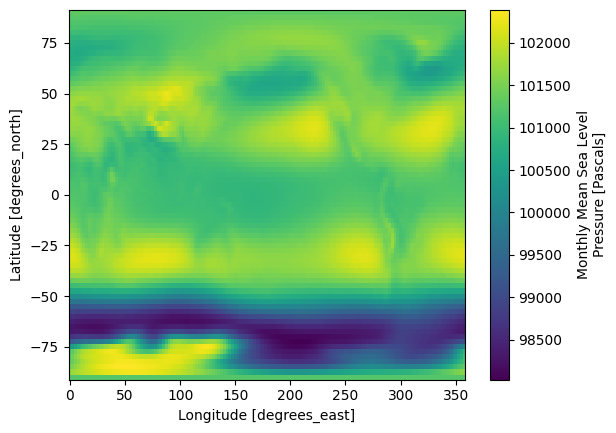

In [6]:
mn.mslp.plot.pcolormesh(x="lon", y="lat")

This is the arithmetic mean values over the period (1979-2025). The water souraounding Antartica show a much lower average, the equator are netutral and we have two srtreeks of higher pressure north and south of the tropics.

Using the package Cartopy we can plot these values on a globe:

/home/johanmon/.local/share/pipx/venvs/jupyter/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


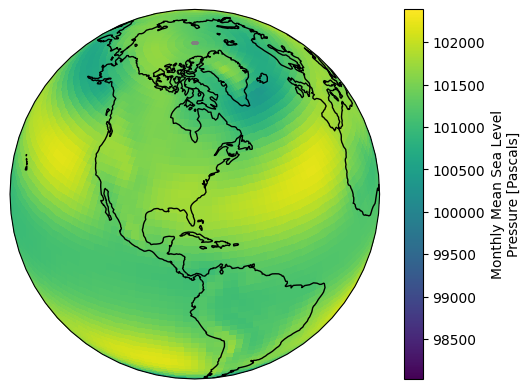

In [8]:
import cartopy.crs as ccrs

p = mn.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(-80, 35), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

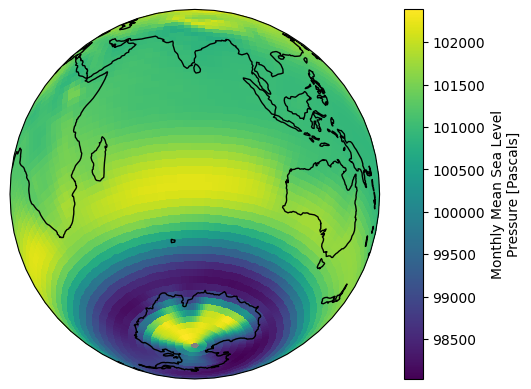

In [9]:
p = mn.mslp.plot(
    subplot_kws=dict(projection=ccrs.Orthographic(80, -35), facecolor="gray"),
    transform=ccrs.PlateCarree(),
)
p.axes.set_global()

p.axes.coastlines();

We now see that the high pressure areas ar over the Atlantic, Pacific and Indian Ocean. The low pressures clealy suraound the Antartic. 